In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot

In [ ]:
train = None
with open("../../Data/PHM2025_training_data/training_data.csv", "r") as f:
    train = pd.read_csv(f)


# Set seed for reproducibility
np.random.seed(42)

# Generate a time index
dates = pd.date_range(start='2024-01-01', periods=100, freq='D')



print("Data generated successfully.")
print(df.head())

Data generated successfully.
             Sensor_A   Sensor_B
2024-01-01  10.496714  48.584629
2024-01-02  10.358450  48.163984
2024-01-03  11.006138  47.821269
2024-01-04  12.529168  47.018992
2024-01-05  12.295015  46.857706


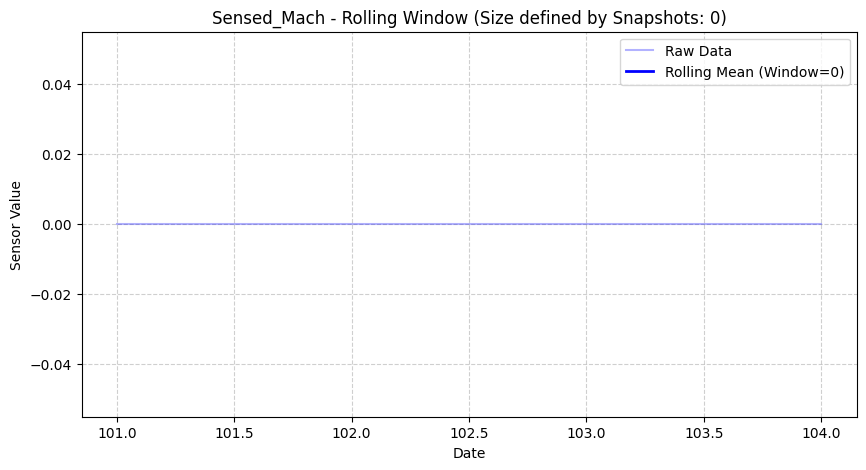

In [13]:
sensors = ["Sensed_Altitude", "Sensed_Mach", "Sensed_Pamb", "Sensed_Pt2", "Sensed_TAT", "Sensed_WFuel",
           "Sensed_VAFN", "Sensed_VBV", "Sensed_Fan_Speed", "Sensed_Core_Speed", "Sensed_T25",
           "Sensed_T3", "Sensed_Ps3", "Sensed_T45", "Sensed_P25", "Sensed_T5"]

sensor_name = "Sensed_Mach"
roll = train.groupby('ESN').apply(lambda x: x.isnull().sum(), include_groups=False)
# window_size = int(train['Snapshot'].max())
window_size = int(roll['Snapshot'].max()*4)

# Calculate Rolling Mean
rolling_mean = roll[sensor_name].rolling(window=window_size).mean()

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(roll.index, roll[sensor_name], label='Raw Data', color='blue', alpha=0.3)
plt.plot(roll.index, rolling_mean, label=f'Rolling Mean (Window={window_size})', color='blue', linewidth=2)

plt.title(f'{sensor_name} - Rolling Window (Size defined by Snapshots: {window_size})')
plt.xlabel('Date')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
